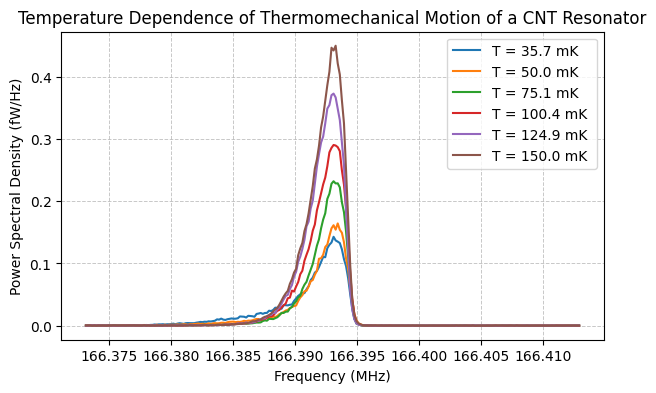

In [1]:
# grc
#HERE
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd        
import qcodes as qc


run_ids = [1263, 1265, 1267, 1299, 1303, 1305, 1309, 1311, 1313, 1315,
           1319, 1321, 1323, 1325, 1329, 1331, 1333, 1335, 1339, 1341, 1343, 1345]

temperatures = [35.6766, 35.6766, 35.6766,
                50.0152, 50.0152, 50.0152,
                75.0531, 75.0531, 75.0531, 75.0531,
                100.3800, 100.3800, 100.3800, 100.3800,
                124.8840, 124.8840, 124.8840, 124.8840,
                149.9940, 149.9940, 149.9940, 149.9940]

qc.config["core"]["db_location"] = r"D:\databases CD11_D7_C1\CD11_D7_C1_part3.db"


def extract_1d(run_id,
               data_1d_name="Resistance",
               setpoint_name="single_gate",
               plot=False):
    ds       = qc.load_by_id(run_id)
    par_data = ds.get_parameter_data(data_1d_name)
    freq_raw = par_data[data_1d_name][setpoint_name]
    df_dict  = ds.to_pandas_dataframe_dict()
    psd_raw  = df_dict[data_1d_name]

    freq = np.asarray(freq_raw).flatten()
    psd  = np.asarray(psd_raw).flatten()

    if plot:
        plt.plot(freq, psd)
        plt.title(f"Measurement {run_id}")
        plt.ylabel("Avg PSD (W/Hz)")
        plt.xlabel("Frequency (MHz)")
        plt.show()

    return freq, psd


temp_data       = {}
frequency_array = None

for run_id, temp in zip(run_ids, temperatures):
    freq, psd = extract_1d(run_id,
                           data_1d_name="avg_avg_psd_nodrive",
                           setpoint_name="freq_param",
                           plot=False)

    if frequency_array is None:
        frequency_array = freq
    temp_data.setdefault(temp, []).append(psd)

plt.figure(figsize=(7, 4))

for temp in sorted(temp_data.keys()):
    traces  = np.vstack(temp_data[temp])   # shape: (n_runs, n_freq)
    avg_psd = traces.mean(axis=0)          # averaged PSD per frequency

    # Noise per temperature = minimum of averaged PSD
    noise_level = avg_psd.min()

   
    df = pd.DataFrame({
        'frequency': frequency_array,
        'psd_':      avg_psd,
        'Noise':     noise_level         
    })


    df['psd_minus_noise'] = (
        df['psd_'] + df['Noise'] - (2 * np.sqrt(df['psd_']) * np.sqrt(df['Noise']))
    )
    plt.ticklabel_format(axis='x', style='plain',useOffset=False)
    plt.ticklabel_format(axis='y', style='plain',useOffset=False)
    plt.plot(df['frequency']*1e-6, df['psd_minus_noise']*1e15,
             label=f"T = {temp:.1f} mK ")
plt.ticklabel_format(axis='x', style='plain',useOffset=False)
plt.ticklabel_format(axis='y', style='plain',useOffset=False)
plt.xlabel("Frequency (MHz)")
plt.ylabel("Power Spectral Density (fW/Hz)")
plt.title("Temperature Dependence of Thermomechanical Motion of a CNT Resonator")


plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)

plt.show()


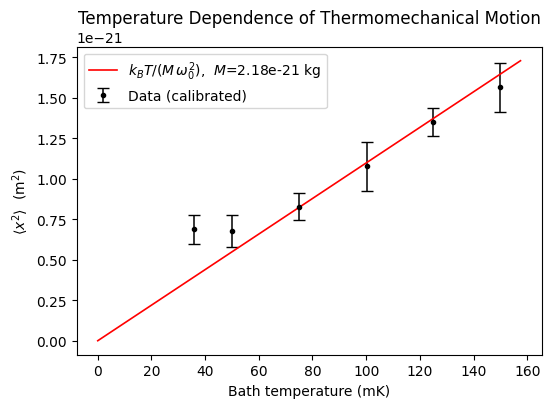

Effective mass M:        2.176e-21 kg
Mode frequency f0:       1.210e+08 Hz
Slope dArea/dT:          1.027e-11 W/K  (through origin)
Calibration factor C:    1.069e-09 m^2/W
<x^2> at 100 mK (theory):1.098e-21 m^2


In [ ]:
# thesis
import scipy.constants as const

temp_data       = {}
frequency_array = None

for run_id, temp in zip(run_ids, temperatures):
    freq, psd = extract_1d(run_id,
                           data_1d_name="avg_avg_psd_nodrive",
                           setpoint_name="freq_param",
                           plot=False)

    if frequency_array is None:
        frequency_array = freq
    temp_data.setdefault(temp, []).append(psd)

# ---- Integrate the thermomechanical peak per run -> "area" in W -------------
area_by_temp = {}

for temp in sorted(temp_data.keys()):
    area_by_temp[temp] = []

    for psd in temp_data[temp]:

        noise_level = psd.min()

        psd_minus_noise = (
            psd + noise_level
            - 2 * np.sqrt(psd) * np.sqrt(noise_level)
        )

        area = np.trapz(psd_minus_noise, frequency_array)   # W
        area_by_temp[temp].append(area)

temps      = []
mean_areas = []
std_areas  = []

for temp in sorted(area_by_temp.keys()):
    areas = np.array(area_by_temp[temp])
    temps.append(temp)
    mean_areas.append(areas.mean())
    std_areas.append(areas.std())

temps      = np.array(temps)        # mK
mean_areas = np.array(mean_areas)   # W
std_areas  = np.array(std_areas)    # W

# ============================================================================
# Equipartition calibration:  area [W]  ->  <x^2> [m^2]
#
# Same mode as in exportfromdatabase2d_spectra_230626.py:
#   d = 2.1 nm, L = 860 nm, sin(pi x/L) shape  ->  M = M_NT / 2
#   f0 = 121 MHz
#
# <x^2>(T) = k_B * T / (M * omega_0^2)
# Slope-only fit (through origin):
#   a = Sum(T * area) / Sum(T^2)       [W/K]
#   C = (k_B / (M * omega_0^2)) / a    [m^2 / W]
# Then <x^2>_meas = C * area.
# ============================================================================
M_C   = 12.011 * 1.66053907e-27
A_hex = 5.2e-20
d_nt  = 2.1e-9
L_nt  = 860e-9
M_eff = 0.5 * (2 * M_C) * (np.pi * d_nt * L_nt / A_hex)

f0      = 121e6
omega_0 = 2 * np.pi * f0

T_K       = temps * 1e-3                                              # K
slope_SI  = np.sum(T_K * mean_areas) / np.sum(T_K**2)                 # W/K, forced through origin
calib     = const.k / (M_eff * omega_0**2 * slope_SI)                 # m^2 / W

x2_meas = mean_areas * calib                                          # m^2
x2_err  = std_areas  * calib                                          # m^2

# Theory line: <x^2> = k_B T / (M omega^2)
T_fine_mK = np.linspace(0, temps.max() * 1.05, 200)
x2_theo   = const.k * (T_fine_mK * 1e-3) / (M_eff * omega_0**2)

plt.figure(figsize=(6, 4))
plt.errorbar(
    temps,
    x2_meas,
    yerr=x2_err,
    fmt="k.", markersize=6,
    capsize=4, elinewidth=1.1, alpha=1,
    label="Data (calibrated)",
)
plt.plot(T_fine_mK, x2_theo, "r-", linewidth=1.2,
         label=fr"$k_B T / (M\,\omega_0^2)$,  $M$={M_eff:.2e} kg")
plt.title("Temperature Dependence of Thermomechanical Motion")
plt.xlabel("Bath temperature (mK)")
plt.ylabel(r"$\langle x^2 \rangle$  (m$^2$)")
#plt.legend()
plt.show()

print(f"Effective mass M:        {M_eff:.3e} kg")
print(f"Mode frequency f0:       {f0:.3e} Hz")
print(f"Slope dArea/dT:          {slope_SI:.3e} W/K  (through origin)")
print(f"Calibration factor C:    {calib:.3e} m^2/W")
print(f"<x^2> at 100 mK (theory):{const.k * 0.1 / (M_eff * omega_0**2):.3e} m^2")


    T (mK)       f0 (MHz)    Γ (kHz)    A_L (fW·kHz²)    A_D (fW·kHz)   floor (fW/Hz)
-------------------------------------------------------------------------------------
      35.7      166.39311      4.359          10.7551          0.0000          8.7276
      50.0      166.39345      3.856           9.2712          0.0000          8.9936
      75.1      166.39311      3.688          10.6176          0.0000          9.4611
     100.4      166.39311      4.023          14.5272          0.0000          9.9771
     124.9      166.39311      3.856          15.6191          0.0000         10.4655
     150.0      166.39328      3.688          16.2331          0.0000         10.9708


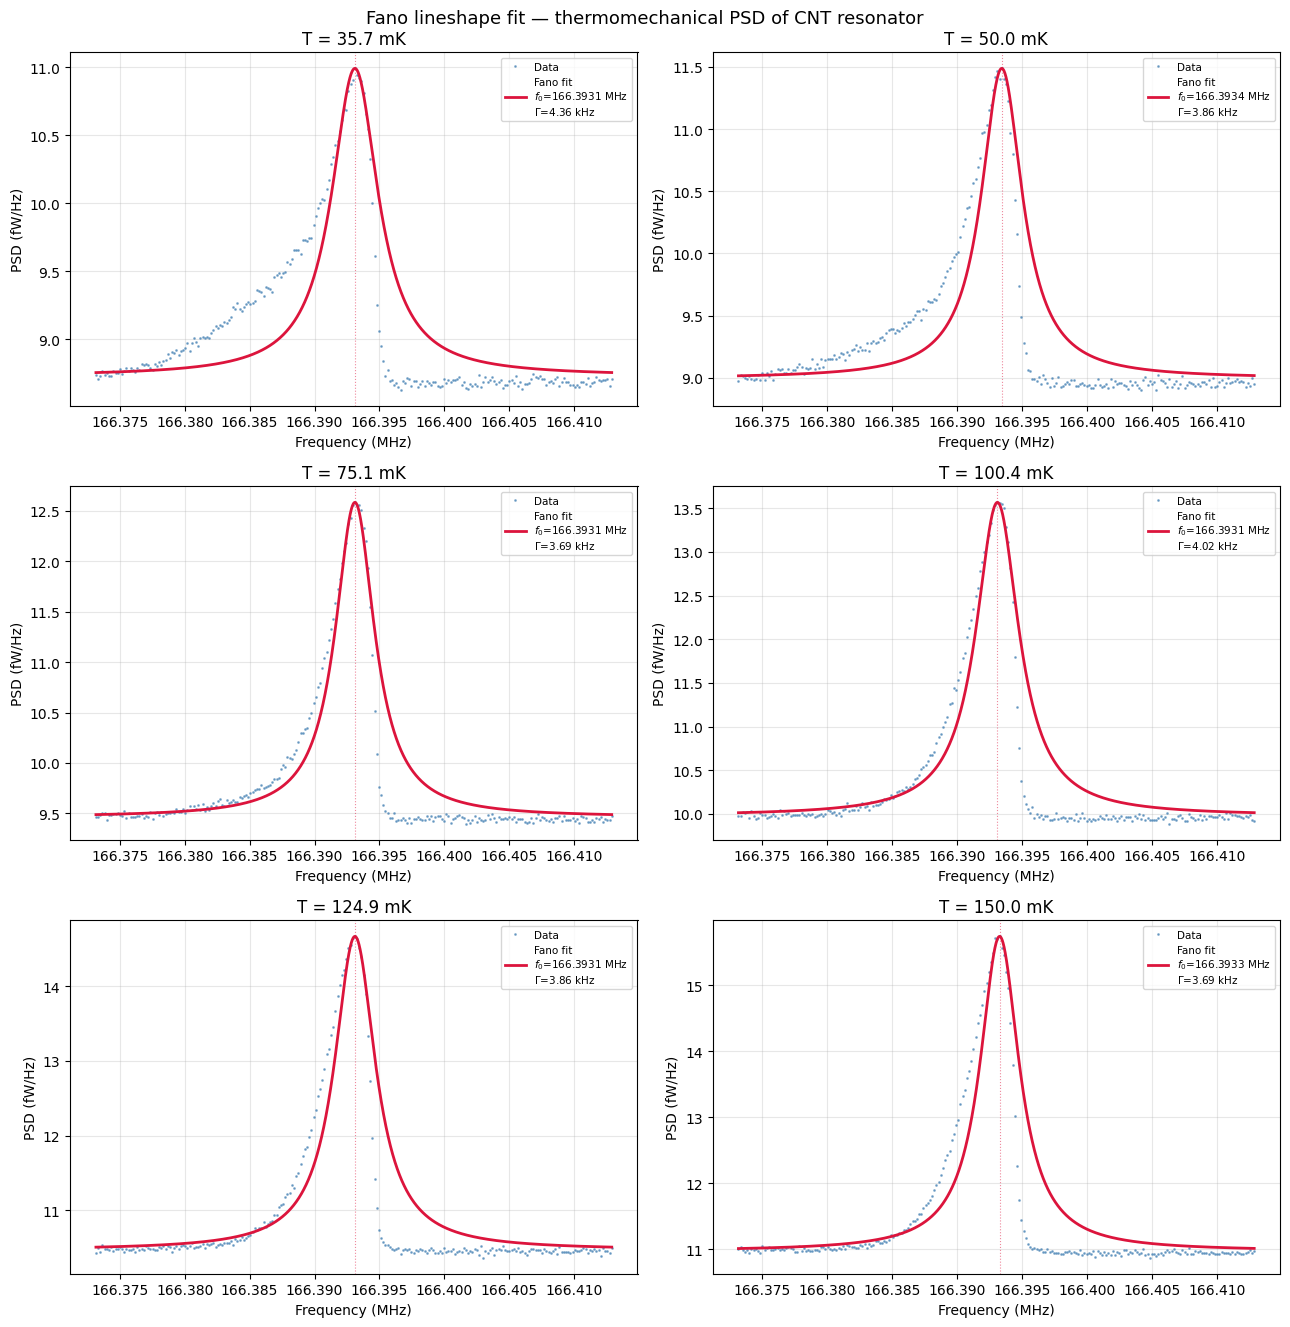

In [3]:
from scipy.optimize import curve_fit

# ---------------------------------------------------------------------------
# Fano model — internally in kHz detuning + fW/Hz for numerical stability
#
#   S(f) = S_floor + (A_L + A_D·Δf) / (Δf² + (Γ/2)²)
#
#   Δf = (f − f0) in kHz
#   A_L : fW/Hz · kHz²   (Lorentzian amplitude, > 0)
#   A_D : fW/Hz · kHz    (dispersive/Fano tilt)
#   S_floor : fW/Hz
#   Returns W/Hz for curve_fit
# ---------------------------------------------------------------------------
def fano_model(f, f0_hz, Gamma_hz, A_L, A_D, S_floor_fw):
    df  = (f - f0_hz) * 1e-3        # → kHz
    G   = Gamma_hz    * 1e-3        # → kHz
    den = df**2 + (G / 2)**2
    return (S_floor_fw + (A_L + A_D * df) / den) * 1e-15   # → W/Hz


# ---------------------------------------------------------------------------
# Fit per temperature
# ---------------------------------------------------------------------------
n_temps = len(temp_data)
ncols   = 2
nrows   = int(np.ceil(n_temps / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(13, 4.5 * nrows))
axes = np.array(axes).flatten()

fit_results = {}
print(f"{'T (mK)':>10}  {'f0 (MHz)':>13}  {'Γ (kHz)':>9}  "
      f"{'A_L (fW·kHz²)':>15}  {'A_D (fW·kHz)':>14}  {'floor (fW/Hz)':>14}")
print("-" * 85)

for ax_idx, temp in enumerate(sorted(temp_data.keys())):
    traces  = np.vstack(temp_data[temp])
    avg_psd = traces.mean(axis=0)          # W/Hz
    psd_fw  = avg_psd * 1e15              # fW/Hz  (O(10) → well-scaled)
    freq    = frequency_array             # Hz

    # ---- initial guesses ------------------------------------------------
    peak_idx = np.argmax(psd_fw)
    f0_guess = freq[peak_idx]

    # Floor from far edges of spectrum (avoids peak contamination)
    n_edge       = max(5, len(freq) // 8)
    S_floor_fw   = np.mean(np.concatenate([psd_fw[:n_edge], psd_fw[-n_edge:]]))
    peak_ht_fw   = max(psd_fw[peak_idx] - S_floor_fw, psd_fw[peak_idx] * 0.05)

    # Half-power linewidth
    half_max    = S_floor_fw + peak_ht_fw / 2
    above       = psd_fw > half_max
    Gamma_guess = (freq[above][-1] - freq[above][0]) if above.sum() >= 2 \
                  else (freq[-1] - freq[0]) * 0.005
    Gamma_kHz   = Gamma_guess * 1e-3

    # A_L in fW/Hz·kHz²:  at resonance S−S_floor = A_L / (Γ/2)²
    A_L_guess = peak_ht_fw * (Gamma_kHz / 2) ** 2
    A_D_guess = 0.0

    p0 = [f0_guess, Gamma_guess, A_L_guess, A_D_guess, S_floor_fw]

    # Fit only within ±12·Γ of the peak (removes irrelevant flat regions)
    window = 12 * Gamma_guess
    mask   = np.abs(freq - f0_guess) < window
    if mask.sum() < 8:
        mask = np.ones(len(freq), dtype=bool)   # fallback: use everything
    freq_w = freq[mask]
    psd_w  = avg_psd[mask]     # W/Hz

    bounds = (
        [f0_guess - window,  Gamma_guess * 0.1, 0,       -np.inf,  0               ],
        [f0_guess + window,  Gamma_guess * 20,  np.inf,   np.inf,  S_floor_fw * 3  ],
    )

    ax = axes[ax_idx]

    try:
        popt, pcov = curve_fit(
            fano_model, freq_w, psd_w,
            p0=p0, bounds=bounds, maxfev=50000,
        )
        perr = np.sqrt(np.diag(pcov))
        fit_results[temp] = {"popt": popt, "perr": perr}

        f0_fit, G_fit, AL_fit, AD_fit, Sf_fit = popt

        f_fine    = np.linspace(freq[0], freq[-1], 5000)
        fit_curve = fano_model(f_fine, *popt) * 1e15

        ax.plot(freq * 1e-6, psd_fw, '.', ms=2, color='steelblue',
                alpha=0.6, label='Data')
        ax.plot(f_fine * 1e-6, fit_curve, '-',  lw=2.0, color='crimson',
                label=(f'Fano fit\n'
                       f'$f_0$={f0_fit*1e-6:.4f} MHz\n'
                       f'$\\Gamma$={G_fit*1e-3:.2f} kHz'))
        ax.axvline(f0_fit * 1e-6, color='crimson', ls=':', lw=0.8, alpha=0.5)

        print(f"{temp:>10.1f}  {f0_fit*1e-6:>13.5f}  {G_fit*1e-3:>9.3f}  "
              f"{AL_fit:>15.4f}  {AD_fit:>14.4f}  {Sf_fit:>14.4f}")

    except RuntimeError as exc:
        ax.text(0.5, 0.5, f'Fit failed:\n{exc}', transform=ax.transAxes,
                ha='center', va='center', fontsize=8)
        print(f"{temp:>10.1f}  -- fit failed: {exc}")

    ax.set_xlabel('Frequency (MHz)')
    ax.set_ylabel('PSD (fW/Hz)')
    ax.set_title(f'T = {temp:.1f} mK')
    ax.legend(fontsize=7.5, loc='upper right')
    ax.ticklabel_format(axis='x', style='plain', useOffset=False)
    ax.grid(alpha=0.3)

for ax in axes[n_temps:]:
    ax.set_visible(False)

fig.suptitle('Fano lineshape fit — thermomechanical PSD of CNT resonator', fontsize=13)
fig.tight_layout()
plt.show()


## Kerr nonlinear lineshape fit

From Micchi / Huang — the thermomechanical spectrum of a **nonlinear (Kerr) oscillator** is a Lorentzian convolved over the classical thermal energy distribution:

$$S_{xx}(f) \propto \int_0^\infty \varepsilon\,e^{-\varepsilon} \frac{\Gamma/\pi}{\bigl(f - f_0 - \beta\,\varepsilon\bigr)^2 + \Gamma^2}\,d\varepsilon, \qquad \varepsilon = E/k_BT$$

- $\beta$ [Hz]: frequency shift at thermal energy $k_BT$ — zero gives a pure Lorentzian  
- $\beta > 0$: resonance shifts up with energy → lineshape skewed to **higher** $f$  
- From $\beta$ and $T$: $K/2\pi = \beta\,\hbar\omega_0 / (k_BT)$ (Kerr coefficient in Hz)

  T (mK)      f0 (MHz)   Gamma (kHz)    beta (Hz)   beta/G   K/2pi (Hz)    eta0          RSS
----------------------------------------------------------------------------------------------
    35.7     166.39483         0.648      -1620.5    -2.50      -362.73    -0.3    2.125e+01
    50.0     166.39479         0.547      -1367.7    -2.50      -218.38    -1.5    9.853e+00
    75.1     166.39464         0.489      -1223.1    -2.50      -130.14    -1.5    7.729e+00
   100.4     166.39467         0.532      -1331.1    -2.50      -105.89    +0.3    1.087e+01
   124.9     166.39451         0.521      -1303.1    -2.50       -83.33    -0.3    1.205e+01
   150.0     166.39459         0.515      -1288.1    -2.50       -68.58    +0.3    1.545e+01


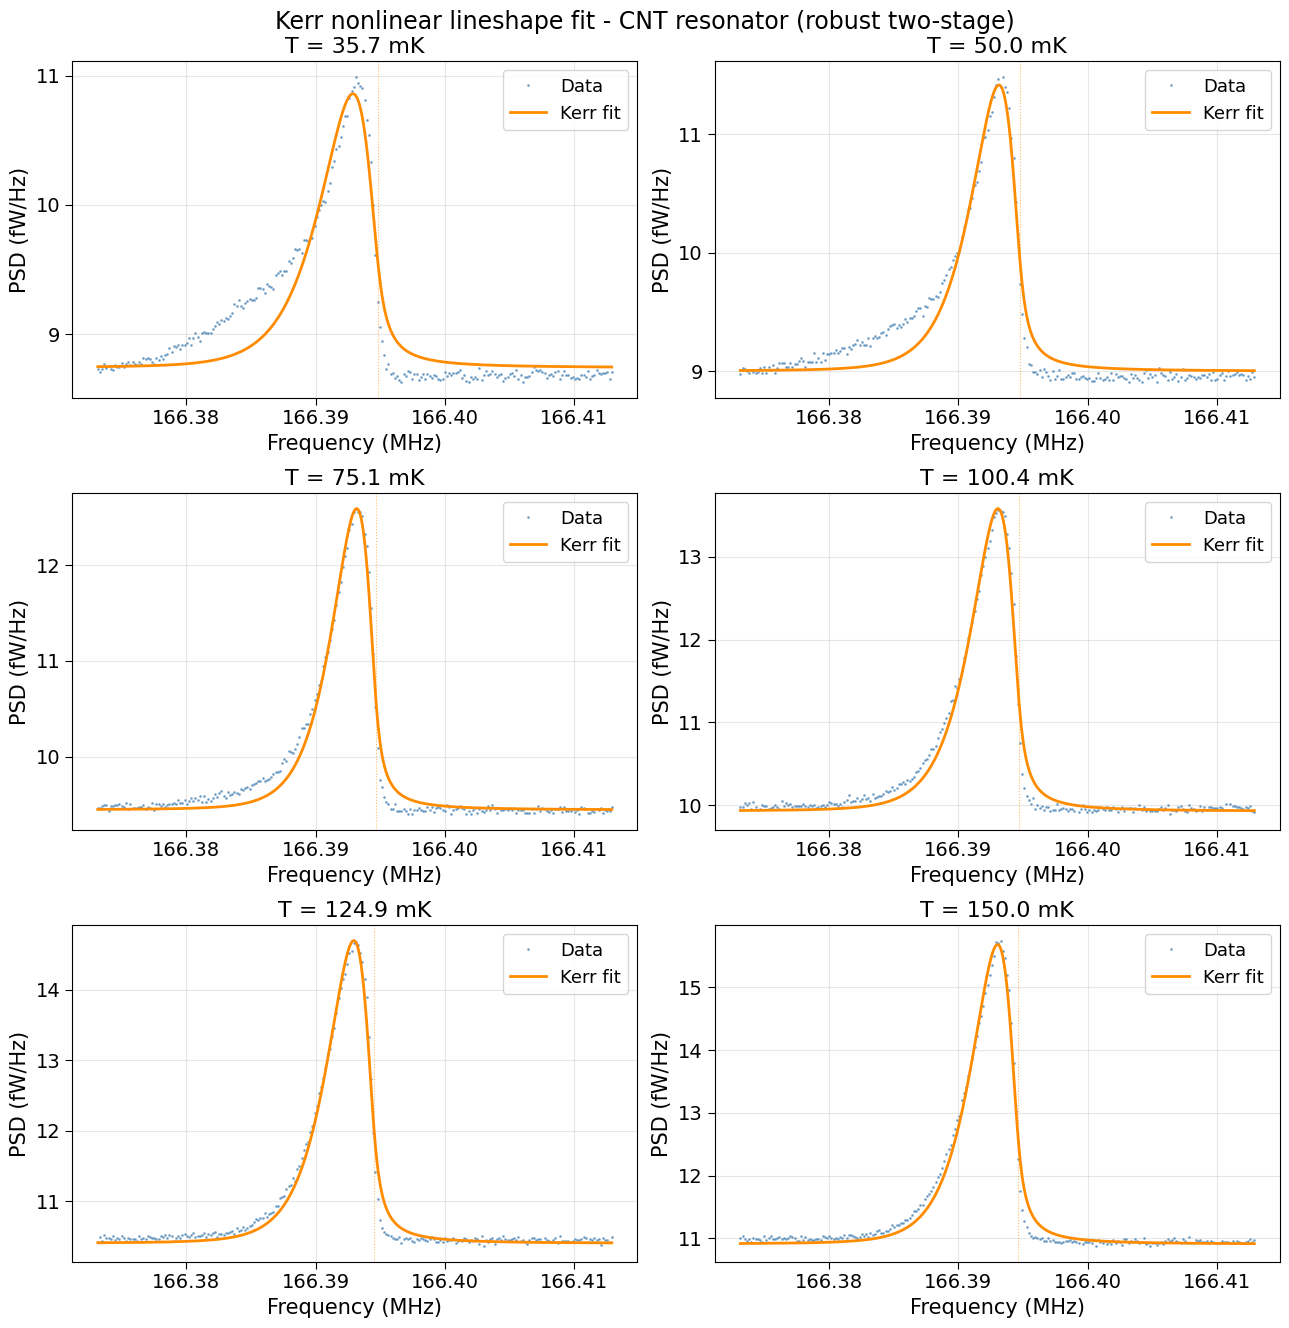

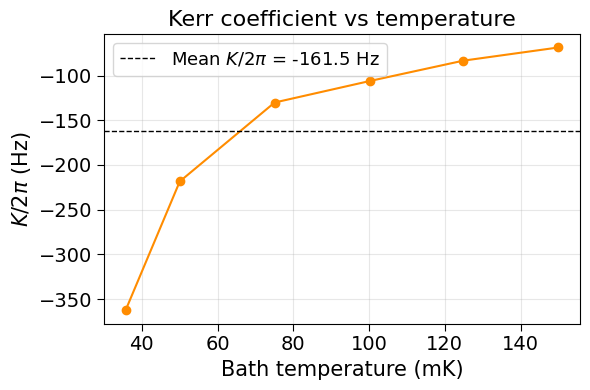

In [4]:
from scipy.optimize import curve_fit
from matplotlib.ticker import MultipleLocator
import scipy.constants as const
import numpy as np
import matplotlib.pyplot as plt

kB   = const.k
hbar = const.hbar

# --- Axis styling (larger fonts, sparser ticks for slide use) ----------------
AX_TICK_FS    = 14     # tick-label fontsize
AX_LABEL_FS   = 15     # x/y label fontsize
AX_TITLE_FS   = 16     # subplot title fontsize
AX_LEGEND_FS  = 13     # legend fontsize
AX_XTICK_STEP = 0.01   # MHz — removes 166.x5 intermediate ticks
AX_YTICK_STEP = 1.0    # fW/Hz — whole-number ticks only (9, 10, 11)

# =============================================================================
# Kerr lineshape fit — ROBUST two-stage version
#
# Why the previous fit was bad: curve_fit's Trust-Region solver stalls when
# parameters span 8+ orders of magnitude (f0 ~ 1.66e8 Hz, beta ~ 1e3 Hz,
# floor ~ 1e-15 W/Hz).  It also got trapped in local minima where a huge
# |beta| + mismatched A / Gamma reproduced the wings but missed the peak
# (hence the flat descending orange curves at 75 and 100 mK).
#
# Fix:
#   1. Internally work in kHz around a pivot frequency and in fW/Hz, so
#      every fit parameter is O(1)-O(10) and the Jacobian is well-scaled.
#   2. Reparameterize beta -> eta = beta / Gamma (dimensionless); bounded.
#   3. Stage 1: pure Lorentzian (beta=0) prefit to lock f0, Gamma, A, floor.
#   4. Stage 2: Kerr refinement, seeded from Stage 1, multi-start over a
#      handful of small eta values, with Gaussian peak-weighted residuals
#      so the fit matches the peak shape rather than the baseline.
# =============================================================================

# --- Kerr integrand weights (eps * exp(-eps), normalised) --------------------
_N_EPS    = 400
_EPS_GRID = np.linspace(0.0, 12.0, _N_EPS)
_W_EPS    = _EPS_GRID * np.exp(-_EPS_GRID)

def _kerr_scaled(df_kHz, df0, G_kHz, eta, A_fWkHz, floor_fW):
    """Kerr lineshape in SCALED units (kHz, fW/Hz). Returns fW/Hz."""
    beta_kHz = eta * G_kHz
    f_eps    = df0 + beta_kHz * _EPS_GRID
    d        = df_kHz[:, None] - f_eps[None, :]
    lor      = (G_kHz / np.pi) / (d*d + G_kHz*G_kHz)
    spec     = np.trapz(_W_EPS[None, :] * lor, _EPS_GRID, axis=1)
    return floor_fW + A_fWkHz * spec

def _lorentz_scaled(df_kHz, df0, G_kHz, A_fWkHz, floor_fW):
    d   = df_kHz - df0
    lor = (G_kHz / np.pi) / (d*d + G_kHz*G_kHz)
    return floor_fW + A_fWkHz * lor

# --- Physics-unit wrappers (used for plotting) -------------------------------
def kerr_model(f_hz, f0_hz, G_hz, beta_hz, A_hz, floor_fW):
    f_eps = f0_hz + beta_hz * _EPS_GRID
    d     = f_hz[:, None] - f_eps[None, :]
    lor   = (G_hz / np.pi) / (d*d + G_hz*G_hz)
    spec  = np.trapz(_W_EPS[None, :] * lor, _EPS_GRID, axis=1)
    return (floor_fW + A_hz * spec) * 1e-15

def lorentz_model(f_hz, f0_hz, G_hz, A_hz, floor_fW):
    d   = f_hz - f0_hz
    lor = (G_hz / np.pi) / (d*d + G_hz*G_hz)
    return (floor_fW + A_hz * lor) * 1e-15

# --- Initial guesses from smoothed spectrum ---------------------------------
def _smooth(y, k=7):
    if k < 3 or len(y) < 2*k:
        return y
    return np.convolve(y, np.ones(k)/k, mode="same")

def _guesses(df_kHz, psd_fw):
    ys   = _smooth(psd_fw, 7)
    peak = int(np.argmax(ys))
    df0  = float(df_kHz[peak])
    n_edge  = max(5, len(df_kHz) // 6)
    floor   = float(np.mean(np.concatenate([psd_fw[:n_edge], psd_fw[-n_edge:]])))
    peak_ht = max(ys[peak] - floor, 0.05 * ys[peak])
    half    = floor + peak_ht/2
    above   = ys > half
    if above.sum() >= 2:
        idx   = np.where(above)[0]
        G_kHz = 0.5 * (df_kHz[idx[-1]] - df_kHz[idx[0]])
    else:
        G_kHz = (df_kHz[-1] - df_kHz[0]) * 0.005
    A_fWkHz = peak_ht * np.pi * G_kHz
    return df0, G_kHz, A_fWkHz, floor

# --- Two-stage fit ----------------------------------------------------------
_ETA_TRIALS = (-1.5, -0.8, -0.3, 0.0, 0.3, 0.8, 1.5)

def fit_kerr(freq_hz, psd_WHz, *, n_fwhm=12, peak_weight=3.0, eta_max=2.5):
    """Two-stage Kerr lineshape fit.

    Returns dict with 'popt' = (f0_hz, Gamma_hz, beta_hz, A_hz, floor_fW),
    'perr' (1-sigma errors), 'rss' (weighted), plus diagnostics.
    """
    pivot  = float(np.median(freq_hz))
    df_kHz = (freq_hz - pivot) * 1e-3
    psd_fw = psd_WHz * 1e15

    # Stage 1 - Lorentzian prefit
    df0_g, G_g, A_g, fl_g = _guesses(df_kHz, psd_fw)
    span  = df_kHz[-1] - df_kHz[0]
    mask1 = np.abs(df_kHz - df0_g) < n_fwhm * G_g
    if mask1.sum() < 20:
        mask1 = np.ones_like(df_kHz, dtype=bool)
    lo = [df0_g - 0.5*span, G_g*0.05, 0.0,    0.0          ]
    hi = [df0_g + 0.5*span, G_g*20,   np.inf, fl_g*5 + 1   ]
    lor_popt, _ = curve_fit(_lorentz_scaled, df_kHz[mask1], psd_fw[mask1],
                            p0=[df0_g, G_g, A_g, fl_g], bounds=(lo, hi), maxfev=20000)

    # Stage 2 - Kerr refinement with peak-weighted residuals
    df0_0, G_0, A_0, fl_0 = lor_popt
    mask2 = np.abs(df_kHz - df0_0) < n_fwhm * G_0
    if mask2.sum() < 20:
        mask2 = np.ones_like(df_kHz, dtype=bool)
    df_w, psd_w = df_kHz[mask2], psd_fw[mask2]
    weight      = 1.0 + (peak_weight - 1.0) * np.exp(-((df_w - df0_0) / (2.0*G_0))**2)
    sigma       = 1.0 / weight

    lo2 = [df0_0 - 0.3*span, G_0*0.25, -eta_max, A_0*0.1,  0              ]
    hi2 = [df0_0 + 0.3*span, G_0*4.0,   eta_max, A_0*10.0, fl_0*3 + 1     ]

    best = dict(popt=None, pcov=None, rss=np.inf, eta0=None)
    for eta0 in _ETA_TRIALS:
        try:
            popt, pcov = curve_fit(
                _kerr_scaled, df_w, psd_w,
                p0=[df0_0, G_0, eta0, A_0, fl_0],
                bounds=(lo2, hi2), sigma=sigma, absolute_sigma=False, maxfev=30000,
            )
            resid = psd_w - _kerr_scaled(df_w, *popt)
            rss   = float(np.sum((resid * weight) ** 2))
            if rss < best["rss"]:
                best.update(popt=popt, pcov=pcov, rss=rss, eta0=eta0)
        except (RuntimeError, ValueError):
            continue

    if best["popt"] is None:   # fall back to Lorentzian if every Kerr start failed
        df0_k, G_k, A_k, fl_k = lor_popt
        popt_s   = np.array([df0_k, G_k, 0.0, A_k, fl_k])
        perr_s   = np.full(5, np.nan)
        rss_used = np.nan
    else:
        popt_s   = best["popt"]
        rss_used = best["rss"]
        perr_s   = np.sqrt(np.diag(best["pcov"]))

    df0_k, G_k, eta, A_fWkHz, fl_fW = popt_s
    f0_hz, G_hz   = pivot + df0_k*1e3, G_k*1e3
    beta_hz, A_hz = eta * G_hz, A_fWkHz*1e3
    popt = np.array([f0_hz, G_hz, beta_hz, A_hz, fl_fW])

    df0_e, G_e_k, eta_e, A_e_k, fl_e = perr_s
    beta_e = np.sqrt((G_hz * eta_e)**2 + (eta * G_e_k*1e3)**2)
    perr   = np.array([df0_e*1e3, G_e_k*1e3, beta_e, A_e_k*1e3, fl_e])

    return dict(popt=popt, perr=perr, rss=rss_used,
                mask=mask2, eta0_best=best.get("eta0"))


# =============================================================================
# Apply fit per temperature and plot
# =============================================================================
n_temps = len(temp_data)
ncols   = 2
nrows   = int(np.ceil(n_temps / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(13, 4.5 * nrows))
axes = np.array(axes).flatten()

kerr_fit_results = {}
print(f"{'T (mK)':>8}  {'f0 (MHz)':>12}  {'Gamma (kHz)':>12}  "
      f"{'beta (Hz)':>11}  {'beta/G':>7}  {'K/2pi (Hz)':>11}  {'eta0':>6}  {'RSS':>11}")
print("-" * 94)

for ax_idx, temp in enumerate(sorted(temp_data.keys())):
    traces  = np.vstack(temp_data[temp])
    avg_psd = traces.mean(axis=0)
    freq    = frequency_array
    T_K     = temp * 1e-3

    res = fit_kerr(freq, avg_psd)
    f0_fit, G_fit, beta_fit, A_fit, Sf_fit = res["popt"]
    omega0_fit = 2 * np.pi * f0_fit
    K_hz       = beta_fit * hbar * omega0_fit / (kB * T_K)

    kerr_fit_results[temp] = dict(popt=res["popt"], perr=res["perr"],
                                  T_K=T_K, rss=res["rss"])

    f_fine    = np.linspace(freq[0], freq[-1], 3000)
    fit_curve = kerr_model(f_fine, *res["popt"]) * 1e15

    ax = axes[ax_idx]
    ax.plot(freq * 1e-6, avg_psd * 1e15, '.', ms=2, color='steelblue',
            alpha=0.6, label='Data')
    ax.plot(f_fine * 1e-6, fit_curve, '-',  lw=2.0, color='darkorange',
            label='Kerr fit')
                   #f'$K/\\Gamma={K_hz/G_fit:.3f}$'))
    ax.axvline(f0_fit * 1e-6, ls=':', lw=0.8, color='darkorange', alpha=0.6)

    # --- Slide-friendly axis styling ---------------------------------------
    ax.set_xlabel('Frequency (MHz)', fontsize=AX_LABEL_FS)
    ax.set_ylabel('PSD (fW/Hz)',     fontsize=AX_LABEL_FS)
    ax.set_title(f'T = {temp:.1f} mK', fontsize=AX_TITLE_FS)
    ax.legend(fontsize=AX_LEGEND_FS, loc='upper right')
    ax.tick_params(axis='both', which='major', labelsize=AX_TICK_FS, length=5)
    ax.tick_params(axis='both', which='minor', length=3)
    ax.xaxis.set_major_locator(MultipleLocator(AX_XTICK_STEP))
    ax.yaxis.set_major_locator(MultipleLocator(AX_YTICK_STEP))
    ax.ticklabel_format(axis='x', style='plain', useOffset=False)
    ax.grid(alpha=0.3)

    eta0_str = f"{res['eta0_best']:+.1f}" if res['eta0_best'] is not None else "---"
    print(f"{temp:>8.1f}  {f0_fit*1e-6:>12.5f}  {G_fit*1e-3:>12.3f}  "
          f"{beta_fit:>11.1f}  {beta_fit/G_fit:>7.2f}  "
          f"{K_hz:>11.2f}  {eta0_str:>6}  {res['rss']:>11.3e}")

for ax in axes[n_temps:]:
    ax.set_visible(False)

fig.suptitle('Kerr nonlinear lineshape fit - CNT resonator (robust two-stage)',
             fontsize=AX_TITLE_FS + 1)
fig.tight_layout()
plt.show()

# =============================================================================
# K/2pi vs temperature - should be constant if purely Kerr
# =============================================================================
if kerr_fit_results:
    T_arr = np.array(sorted(kerr_fit_results.keys()))
    K_arr = np.array([
        kerr_fit_results[t]["popt"][2]
        * hbar * 2 * np.pi * kerr_fit_results[t]["popt"][0]
        / (kB * kerr_fit_results[t]["T_K"])
        for t in T_arr
    ])
    fig2, ax2 = plt.subplots(figsize=(6, 4))
    ax2.plot(T_arr, K_arr, 'o-', color='darkorange', lw=1.5)
    ax2.axhline(np.mean(K_arr), ls='--', color='k', lw=1,
                label=f'Mean $K/2\\pi$ = {np.mean(K_arr):.1f} Hz')
    ax2.set_xlabel('Bath temperature (mK)', fontsize=AX_LABEL_FS)
    ax2.set_ylabel('$K/2\\pi$ (Hz)',        fontsize=AX_LABEL_FS)
    ax2.set_title('Kerr coefficient vs temperature',  fontsize=AX_TITLE_FS)
    ax2.tick_params(axis='both', which='major', labelsize=AX_TICK_FS, length=5)
    ax2.legend(fontsize=AX_LEGEND_FS)
    ax2.grid(alpha=0.3)
    fig2.tight_layout()
    plt.show()
